**Hypotesis: Does the model rely on temporal and traffic-source shortcut features
(Month, TrafficType) instead of genuine behavioral signals,
causing performance collapse under distribution shift?**

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

RANDOM_STATE = 42

loading dataset and removing PageValue feature

In [7]:
DATA_PATH = r"C:\Users\MOHAMED ALI REBBAH\Documents\GitHub\When-ML-fails\data\online_shoppers_intention.csv"

df = pd.read_csv(DATA_PATH)

df = df.drop(columns=['PageValues'])

separating features and target

In [8]:
X = df.drop(columns=['Revenue'])
y = df['Revenue']

Feature Types

In [23]:
categorical_features = X.select_dtypes(
    include=['str', 'bool']
).columns.tolist()

numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: ['Month', 'VisitorType', 'Weekend']
Numerical: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']


Preprocessing

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

Train/Test Split (random)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

Model Pipeline

In [12]:
model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric='logloss'
    ))
])

training model

In [13]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

Predictions

In [14]:
y_pred = model.predict(X_test)

y_proba = model.predict_proba(X_test)[:, 1]

Evaluating Model

In [15]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_proba))

Accuracy : 0.8471208434712084
Precision: 0.5268817204301075
Recall   : 0.12827225130890052
F1 Score : 0.2063157894736842
ROC AUC  : 0.7618278381284482


Classification Report

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.86      0.98      0.92      2084
        True       0.53      0.13      0.21       382

    accuracy                           0.85      2466
   macro avg       0.69      0.55      0.56      2466
weighted avg       0.81      0.85      0.81      2466



Confusion Matrix

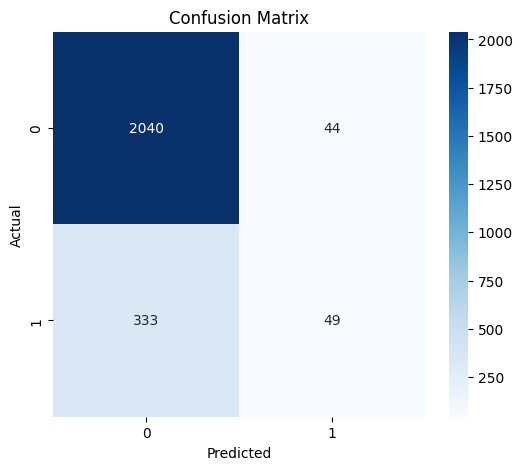

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

_model predicts:
-non-purchase extremely well
-purchase very poorly_

Feature Importance

In [18]:
ohe = model.named_steps['preprocessing'].named_transformers_['cat']

encoded_cat_features = ohe.get_feature_names_out(categorical_features)

all_features = np.concatenate([
    encoded_cat_features,
    numerical_features
])

In [19]:
importances = model.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
7,Month_Nov,0.078449
22,ExitRates,0.075299
12,VisitorType_Returning_Visitor,0.074813
5,Month_Mar,0.043222
20,ProductRelated_Duration,0.040915
9,Month_Sep,0.039876
23,SpecialDay,0.036948
21,BounceRates,0.036121
6,Month_May,0.035375
8,Month_Oct,0.034812


multiple Month indicators dominate the model in addition to VisitorType but TrafficType is not a major predictive signal cotrary to what we suspected after EDA

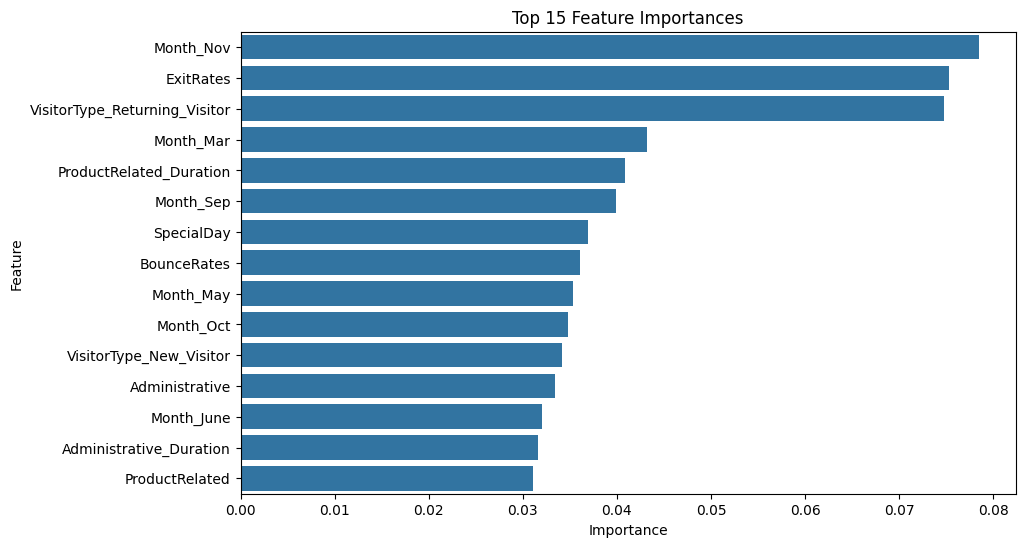

In [20]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Feature Importances")

plt.show()

**we won't confirm the hypothesis but this indicates that the model relies excessively on temporal features (Month) that correlate with purchase probability in the training distribution. This dependence may reduce robustness under temporal distribution shift. Thus in the next notebook we will force the model to fail by training it on the first months of the year and testing on the later ones.**
